In [23]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

In [ ]:
#  Ornstein-Uhlenbeck process, used e.g. in the Vasicek short-rate model

# Monte Carlo simulation of the Ornstein-Uhlenbeck process
# dX = alpha*(mu-X)*dt + sigma*dW


In [2]:
# Define the parameters and the time grid

npaths = 20000 # number of paths
T = 1 # time horzion
nsteps = 200 # number of time steps
dt = T / nsteps # time step
t = np.arange(0, T + dt, dt) # observation times
alpha = 5
mu = 0.07
sigma = 0.07
X0 = 0.03

In [12]:
# Monte Carlo simulation

# Allocate and initialize all paths
X = np.zeros((nsteps + 1, npaths))
X[0, :] = X0  # Initial value for all paths

# Sample standard Gaussian random numbers
N = np.random.randn(nsteps, npaths)

In [ ]:
# Standard deviation for a time step

# sdev = sigma * np.sqrt(dt)  # plain Euler-Maruyama

sdev = sigma * np.sqrt((1 - np.exp(-2 * alpha * dt)) / (2 * alpha))  # Euler-Maruyama with analytic moments which is used in OU proccess

In [ ]:
# Compute and accumulate the increments
for i in range(nsteps):
    X[i + 1, :] = mu + (X[i, :] - mu) * np.exp(-alpha * dt) + sdev * N[i, :]

EX = mu + (X0 - mu) * np.exp(-alpha * t)  # Expected path


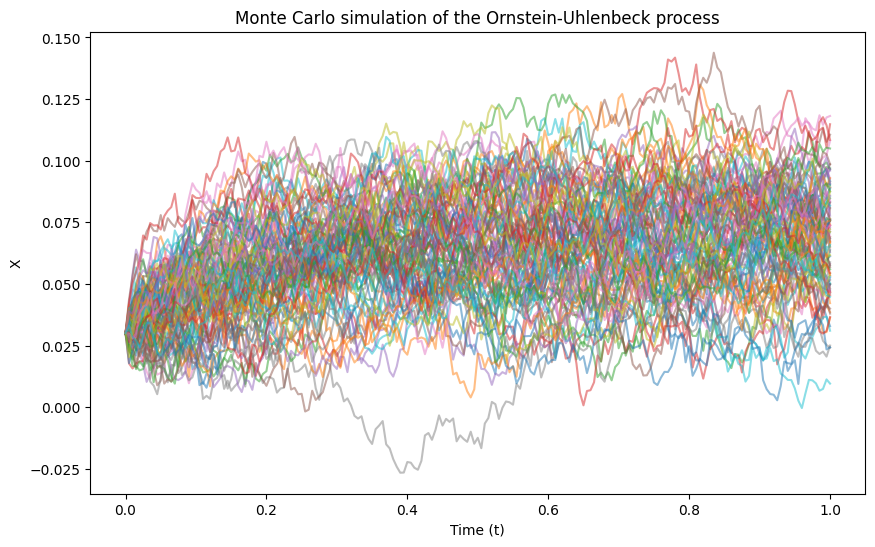

In [16]:
plt.figure(figsize=(10, 6))
plt.plot(t, X[:, :100], alpha=0.5)  # Plot a subset of paths for clarity
plt.xlabel('Time (t)')
plt.ylabel('X')
plt.title('Monte Carlo simulation of the Ornstein-Uhlenbeck process')
plt.show()

Text(0.5, 1.0, 'Ornstein-Uhlenbeck process $dX = \\alpha(\\mu - X)dt + \\sigma dW$')

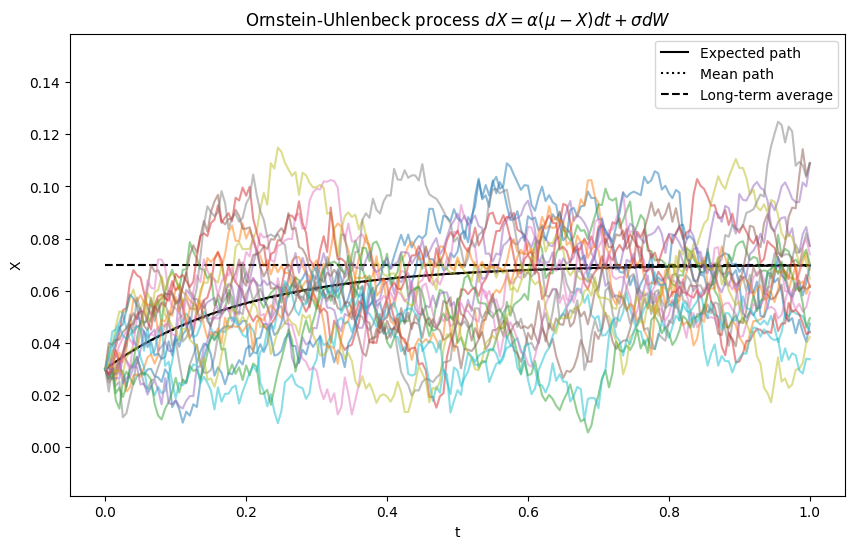

In [ ]:
# 1. Expected, mean, and sample paths, long-term average

plt.figure(figsize=(10, 6))
plt.plot(t, EX, 'k', label='Expected path')

plt.plot(t, np.mean(X, axis=1), 'k:', label='Mean path')

plt.plot(t, mu * np.ones_like(t), 'k--', label='Long-term average')

plt.plot(t, X[:, ::1000], alpha=0.5)  # Plot a subset of paths for clarity

plt.legend()
plt.xlabel('t')
plt.ylabel('X')
sdevinfty = sigma / np.sqrt(2 * alpha)
plt.ylim([mu - 4 * sdevinfty, mu + 4 * sdevinfty])
plt.title('Ornstein-Uhlenbeck process $dX = \\alpha(\\mu - X)dt + \\sigma dW$')


Text(0.5, 1.0, 'Ornstein-Uhlenbeck process: variance')

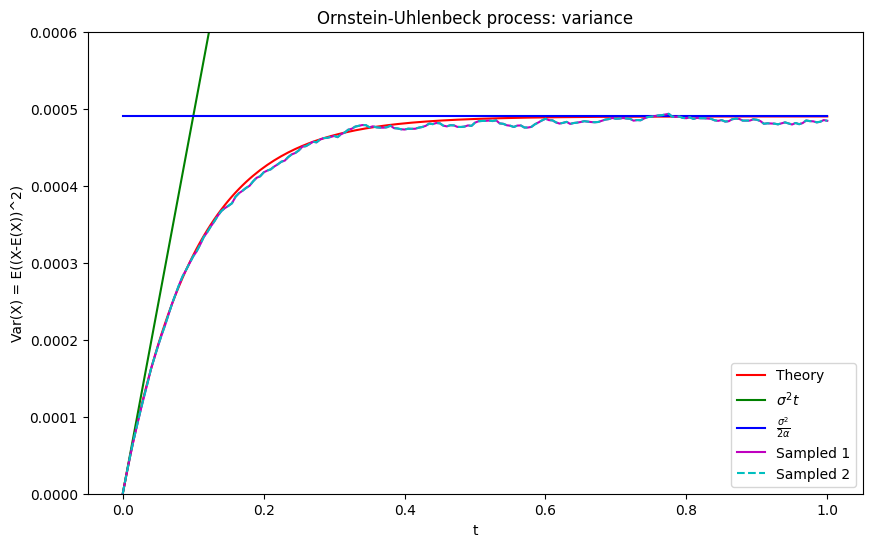

In [20]:
# 2. Variance = mean square deviation

plt.figure(figsize=(10, 6))
plt.plot(t, sigma**2 / (2 * alpha) * (1 - np.exp(-2 * alpha * t)), 'r', label='Theory')
plt.plot(t, sigma**2 * t, 'g', label='$\\sigma^2 t$')
plt.plot(t, sigma**2 / (2 * alpha) * np.ones_like(t), 'b', label='$\\frac{\\sigma^2}{2\\alpha}$')
plt.plot(t, np.var(X, axis=1), 'm', label='Sampled 1')
plt.plot(t, np.mean((X - EX[:, None])**2, axis=1), 'c--', label='Sampled 2')
plt.legend()
plt.xlabel('t')
plt.ylabel('Var(X) = E((X-E(X))^2)')
plt.ylim([0, 0.0006])
plt.title('Ornstein-Uhlenbeck process: variance')

Text(0.5, 1.0, 'Ornstein-Uhlenbeck process: mean absolute deviation')

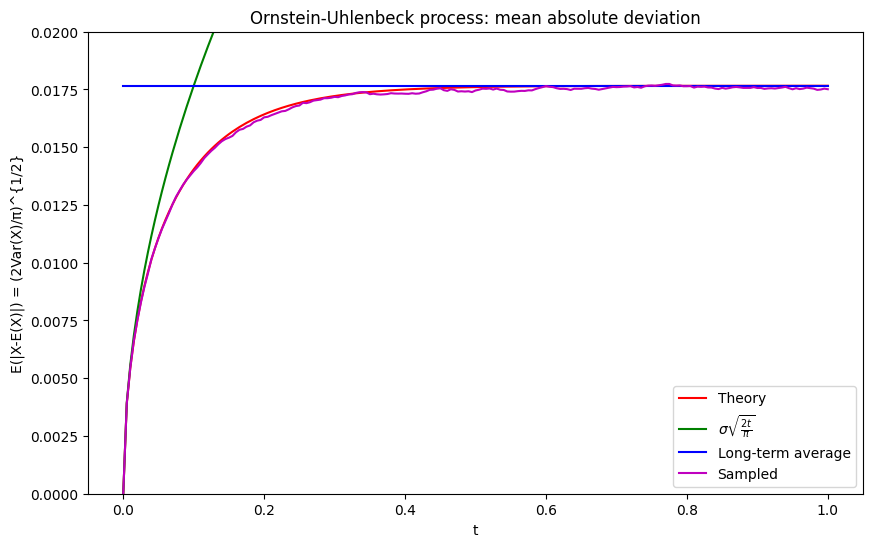

In [21]:
# 3. Mean absolute deviation

plt.figure(figsize=(10, 6))
plt.plot(t, sigma * np.sqrt((1 - np.exp(-2 * alpha * t)) / (np.pi * alpha)), 'r', label='Theory')
plt.plot(t, sigma * np.sqrt(2 * t / np.pi), 'g', label='$\\sigma \\sqrt{\\frac{2t}{\\pi}}$')
plt.plot(t, sigma / np.sqrt(np.pi * alpha) * np.ones_like(t), 'b', label='Long-term average')
plt.plot(t, np.mean(np.abs(X - EX[:, None]), axis=1), 'm', label='Sampled')
plt.legend()
plt.xlabel('t')
plt.ylabel('E(|X-E(X)|) = (2Var(X)/π)^{1/2}')
plt.ylim([0, 0.02])
plt.title('Ornstein-Uhlenbeck process: mean absolute deviation')